# ENM 5310 — Aurora precipitation fine-tuning (Head-only, publishable baseline)

Goal: train a small precipitation head on top of **frozen AuroraSmallPretrained**.

This notebook is meant to be the **"results" notebook** (training + eval + plots + saved checkpoints).


## 0) Config (edit only this cell)

In [1]:
from pathlib import Path

# Where your existing NetCDFs live (same folder you used)
DATA_DIR = Path("./downloads/era5")

# Dates you have downloaded (start small for deadline; you can expand later)
# Expected file naming (same as your baseline):
#   {date}-surface-level.nc
#   {date}-atmospheric.nc
#   {date}-tp-hourly-01_to_06.nc   (or equivalent per day)
TRAIN_DATES = [
    "2023-01-01",
]
VAL_DATES = [
    # "2023-01-02",  # if you don't have it, set VAL_DATES=[]
]

# Training
EPOCHS = 1
LR = 1e-3
BATCH_SIZE = 1   # keep 1 for now (global 720x1440)

# GPU strategy
# If this OOMs, set BACKBONE_ON_GPU=False and we'll run Aurora on CPU and head on GPU.
BACKBONE_ON_GPU = False
HEAD_ON_GPU = True

# Output
OUT_DIR = Path("./runs/aurora_tp_head")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = OUT_DIR / "precip_head.pt"

print("Config loaded.")

Config loaded.


In [2]:
################################
## Downloading data if needed ##
################################


from datetime import datetime, timedelta
from pathlib import Path
import cdsapi

c = cdsapi.Client()
out = Path("downloads/era5")
out.mkdir(parents=True, exist_ok=True)

def download_day(date_str):
    y, m, d = date_str.split("-")

    surf = out / f"{date_str}-surface-level.nc"
    atm  = out / f"{date_str}-atmospheric.nc"
    tp   = out / f"{date_str}-tp-hourly-01_to_06.nc"

    if not surf.exists():
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": [
                    "2m_temperature",
                    "10m_u_component_of_wind",
                    "10m_v_component_of_wind",
                    "mean_sea_level_pressure",
                ],
                "year": y, "month": m, "day": d,
                "time": ["00:00", "06:00", "12:00", "18:00"],
                "format": "netcdf",
            },
            str(surf),
        )

    if not atm.exists():
        c.retrieve(
            "reanalysis-era5-pressure-levels",
            {
                "product_type": "reanalysis",
                "variable": [
                    "temperature",
                    "u_component_of_wind",
                    "v_component_of_wind",
                    "specific_humidity",
                    "geopotential",
                ],
                "pressure_level": ["1000","850","500","200"],
                "year": y, "month": m, "day": d,
                "time": ["00:00", "06:00", "12:00", "18:00"],
                "format": "netcdf",
            },
            str(atm),
        )

    if not tp.exists():
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": ["total_precipitation"],
                "year": y, "month": m, "day": d,
                "time": [f"{h:02d}:00" for h in range(1, 7)],
                "format": "netcdf",
            },
            str(tp),
        )

    print("✓", date_str)


for d in TRAIN_DATES + VAL_DATES:
    download_day(d)

2025-12-17 17:02:12,474 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


✓ 2023-01-01


## 1) Imports + device

In [3]:
import json
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import xarray as xr

from aurora import Batch, Metadata
from aurora import AuroraSmallPretrained

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


torch: 2.7.1+cu128
cuda available: True
device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2) Load normalization stats (from your baseline)

In [4]:
STATS_PATH = Path("./tp_normalization.json")
assert STATS_PATH.exists(), "Missing tp_normalization.json (run baseline notebook Step 5)."

with open(STATS_PATH, "r") as f:
    stats = json.load(f)

MU = float(stats["mean"])
STD = float(stats["std"])
print("Loaded stats:", stats)
print("MU, STD:", MU, STD)


Loaded stats: {'target': 'log1p_tp_6h', 'mean': 0.0005497062811627984, 'std': 0.0019855170976370573, 'units': 'log(1 + meters)'}
MU, STD: 0.0005497062811627984 0.0019855170976370573


## 3) Helper: build Batch + target for one day

In [5]:
def build_paths(date_str: str):
    """Returns (surf_path, atm_path, tp_path, static_path)."""
    surf = DATA_DIR / f"{date_str}-surface-level.nc"
    atm  = DATA_DIR / f"{date_str}-atmospheric.nc"
    tp   = DATA_DIR / f"{date_str}-tp-hourly-01_to_06.nc"
    static = DATA_DIR / "static.nc"
    return surf, atm, tp, static


def build_batch(date_str: str) -> Batch:
    surf_path, atm_path, _, static_path = build_paths(date_str)
    assert surf_path.exists(), f"Missing {surf_path}"
    assert atm_path.exists(), f"Missing {atm_path}"
    assert static_path.exists(), f"Missing {static_path}"

    static_ds = xr.open_dataset(static_path)
    surf_ds   = xr.open_dataset(surf_path)
    atm_ds    = xr.open_dataset(atm_path)

    # NOTE: you used [:2] in baseline. We'll keep that: 2 time steps (t0, t1)
    b = Batch(
        surf_vars={
            "2t":  torch.from_numpy(surf_ds["t2m"].values[:2][None]),
            "10u": torch.from_numpy(surf_ds["u10"].values[:2][None]),
            "10v": torch.from_numpy(surf_ds["v10"].values[:2][None]),
            "msl": torch.from_numpy(surf_ds["msl"].values[:2][None]),
        },
        static_vars={
            "z":   torch.from_numpy(static_ds["z"].values[0]),
            "slt": torch.from_numpy(static_ds["slt"].values[0]),
            "lsm": torch.from_numpy(static_ds["lsm"].values[0]),
        },
        atmos_vars={
            "t": torch.from_numpy(atm_ds["t"].values[:2][None]),
            "u": torch.from_numpy(atm_ds["u"].values[:2][None]),
            "v": torch.from_numpy(atm_ds["v"].values[:2][None]),
            "q": torch.from_numpy(atm_ds["q"].values[:2][None]),
            "z": torch.from_numpy(atm_ds["z"].values[:2][None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(surf_ds.latitude.values),
            lon=torch.from_numpy(surf_ds.longitude.values),
            time=(surf_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
            atmos_levels=tuple(int(l) for l in atm_ds.pressure_level.values),
        ),
    )

    # Close datasets early
    static_ds.close(); surf_ds.close(); atm_ds.close()
    return b


def build_target(date_str: str) -> torch.Tensor:
    """Returns y_norm with shape [1,1,720,1440] on CPU."""
    _, _, tp_path, _ = build_paths(date_str)
    assert tp_path.exists(), f"Missing {tp_path}"

    tp_ds = xr.open_dataset(tp_path)
    tp = tp_ds["tp"]

    # Sum hours 1..6 (your baseline)
    tp6h = tp.sum(dim="valid_time")

    y = torch.from_numpy(tp6h.values.astype("float32"))  # [H,W]
    y_log = torch.log1p(y)
    y_log_bchw = y_log[None, None].contiguous()  # [1,1,H,W]

    y_norm = (y_log_bchw - MU) / STD

    # Safety crop to match Aurora's 720 latitude grid
    y_norm = y_norm[:, :, :720, :].contiguous()

    tp_ds.close()
    return y_norm


## 4) Helper: pack Aurora features

In [6]:
def pack_surf_features(pred_batch: Batch) -> torch.Tensor:
    x2t  = pred_batch.surf_vars["2t"]
    x10u = pred_batch.surf_vars["10u"]
    x10v = pred_batch.surf_vars["10v"]
    xmsl = pred_batch.surf_vars["msl"]

    X = torch.cat([x2t, x10u, x10v, xmsl], dim=1).float()  # [B,4,H,W]

    # --- THE FIX: per-channel standardization (per sample) ---
    mean = X.mean(dim=(2,3), keepdim=True)
    std  = X.std(dim=(2,3), keepdim=True).clamp_min(1e-6)
    X = (X - mean) / std

    return X


## 5) Model: Aurora (frozen) + Precip head (trainable)

In [7]:
class PrecipHead(nn.Module):
    def __init__(self, in_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=1),
        )
    def forward(self, x):
        return self.net(x)


model = AuroraSmallPretrained(use_lora=False)
model.load_checkpoint("microsoft/aurora", "aurora-0.25-small-pretrained.ckpt")
model.eval()

# Freeze backbone
for p in model.parameters():
    p.requires_grad_(False)

head = PrecipHead(in_ch=4)

# Place models
if BACKBONE_ON_GPU and device.type == "cuda":
    model = model.to("cuda")
else:
    model = model.to("cpu")

if HEAD_ON_GPU and device.type == "cuda":
    head = head.to("cuda")
else:
    head = head.to("cpu")

print("Backbone device:", next(model.parameters()).device)
print("Head device:", next(head.parameters()).device)


Backbone device: cpu
Head device: cuda:0


## 6) Minimal training/eval loops (head-only)

Important rules (so we don't blow VRAM):
- Aurora forward runs under `torch.inference_mode()`.
- We delete `pred` and `batch_*` every iteration.
- We only keep the head gradients.


In [8]:
loss_fn = nn.MSELoss()
opt = optim.Adam(head.parameters(), lr=LR)

def move_batch(b: Batch, dev: torch.device) -> Batch:
    return b.to(str(dev))


@torch.no_grad()
def eval_one(date_str: str) -> float:
    model.eval(); head.eval()

    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    # Move batch to backbone device
    bb_dev = next(model.parameters()).device
    b_dev = move_batch(b, bb_dev)

    pred = model(b_dev)
    X = pack_surf_features(pred)

    # Move X + y to head device
    h_dev = next(head.parameters()).device
    X = X.to(h_dev)
    y = y.to(h_dev)

    yhat = head(X)
    loss = loss_fn(yhat, y).item()

    # cleanup
    del b, b_dev, pred, X, y, yhat
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return float(loss)


def train_one_epoch(dates):
    model.eval()      # always frozen
    head.train()

    losses = []

    for i, date_str in enumerate(dates):
        # Build sample
        b = build_batch(date_str)
        y = build_target(date_str)  # CPU

        # Move batch to backbone device
        bb_dev = next(model.parameters()).device
        b_dev = move_batch(b, bb_dev)

        # Aurora forward (no grad)
        with torch.inference_mode():
            pred = model(b_dev)
            X = pack_surf_features(pred)

        # Move X + y to head device
        h_dev = next(head.parameters()).device
        X = X.to(h_dev)
        y = y.to(h_dev)

        # Head training
        opt.zero_grad(set_to_none=True)
        yhat = head(X)
        loss = loss_fn(yhat, y)
        loss.backward()
        opt.step()

        losses.append(loss.item())

        # cleanup aggressively
        del b, b_dev, pred, X, y, yhat, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

        if (i % 1) == 0:
            print(f"  train sample {i+1}/{len(dates)} | loss {losses[-1]:.6f} | date {date_str}")

    return float(np.mean(losses)) if len(losses) else float("nan")


## 7) Run training + validation

In [9]:
print("TRAIN_DATES:", TRAIN_DATES)
print("VAL_DATES:", VAL_DATES)

history = {"train_loss": [], "val_loss": []}

for ep in range(EPOCHS):
    print(f"\n=== Epoch {ep+1}/{EPOCHS} ===")
    train_loss = train_one_epoch(TRAIN_DATES)
    history["train_loss"].append(train_loss)

    if len(VAL_DATES) > 0:
        vals = [eval_one(d) for d in VAL_DATES]
        val_loss = float(np.mean(vals))
    else:
        val_loss = float("nan")

    history["val_loss"].append(val_loss)
    print(f"Epoch {ep+1}: train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    # Save checkpoint (head only)
    torch.save({
        "head_state_dict": head.state_dict(),
        "config": {
            "TRAIN_DATES": TRAIN_DATES,
            "VAL_DATES": VAL_DATES,
            "LR": LR,
            "EPOCHS": EPOCHS,
            "BACKBONE_ON_GPU": BACKBONE_ON_GPU,
            "HEAD_ON_GPU": HEAD_ON_GPU,
            "MU": MU,
            "STD": STD,
        },
        "history": history,
    }, CHECKPOINT_PATH)
    print("Saved:", CHECKPOINT_PATH)

print("\nDone.")
print("history:", history)


TRAIN_DATES: ['2023-01-01']
VAL_DATES: []

=== Epoch 1/1 ===
  train sample 1/1 | loss 1.065274 | date 2023-01-01
Epoch 1: train_loss=1.065274 | val_loss=nan
Saved: runs\aurora_tp_head\precip_head.pt

Done.
history: {'train_loss': [1.0652744770050049], 'val_loss': [nan]}


## 8) Quick qualitative plot (one day)
This is what you can screenshot for your report: target vs prediction.

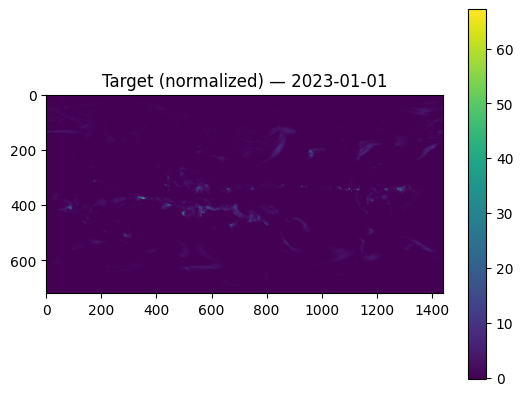

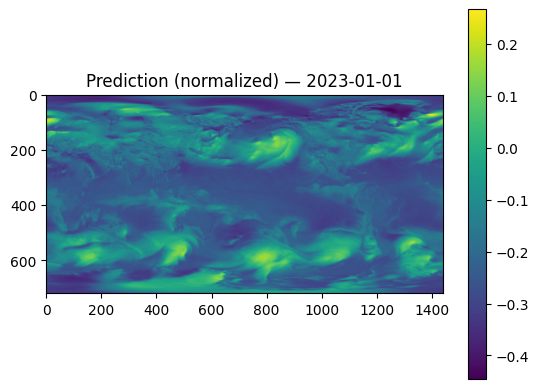

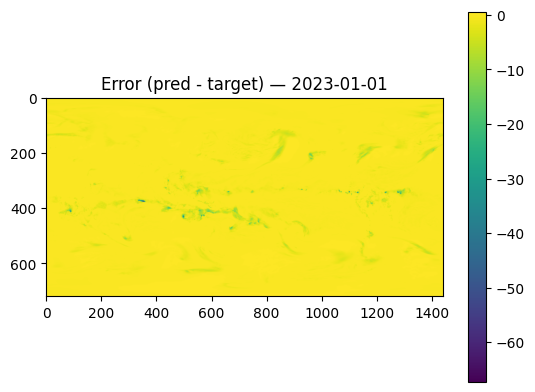

In [10]:
import matplotlib.pyplot as plt

def predict_map(date_str: str):
    model.eval(); head.eval()
    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    h_dev  = next(head.parameters()).device
    b_dev = move_batch(b, bb_dev)

    with torch.inference_mode():
        pred = model(b_dev)
        X = pack_surf_features(pred).to(h_dev)
        yhat = head(X)

    # bring to CPU numpy
    yhat_cpu = yhat.detach().to("cpu").squeeze().numpy()
    y_cpu    = y.detach().to("cpu").squeeze().numpy()

    # cleanup
    del b, b_dev, pred, X, yhat, y
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return y_cpu, yhat_cpu


SHOW_DATE = TRAIN_DATES[0]
y_true, y_pred = predict_map(SHOW_DATE)

plt.figure()
plt.title(f"Target (normalized) — {SHOW_DATE}")
plt.imshow(y_true)
plt.colorbar()
plt.show()

plt.figure()
plt.title(f"Prediction (normalized) — {SHOW_DATE}")
plt.imshow(y_pred)
plt.colorbar()
plt.show()

plt.figure()
plt.title(f"Error (pred - target) — {SHOW_DATE}")
plt.imshow(y_pred - y_true)
plt.colorbar()
plt.show()


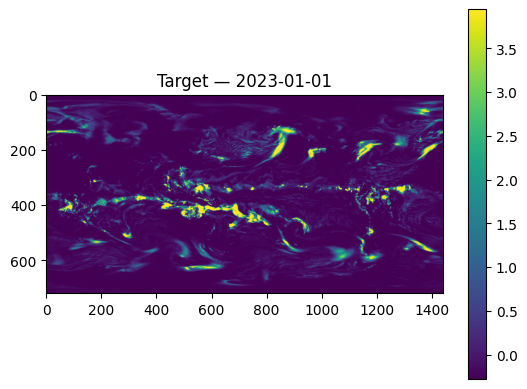

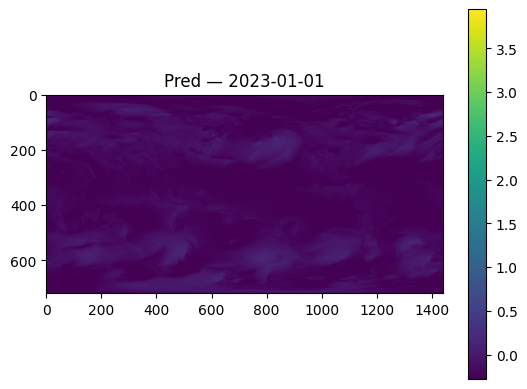

In [11]:
vmin = np.percentile(y_true, 1)
vmax = np.percentile(y_true, 99)

plt.figure(); plt.title(f"Target — {SHOW_DATE}"); plt.imshow(y_true, vmin=vmin, vmax=vmax); plt.colorbar(); plt.show()
plt.figure(); plt.title(f"Pred — {SHOW_DATE}");   plt.imshow(y_pred, vmin=vmin, vmax=vmax); plt.colorbar(); plt.show()


## 9) If GPU OOM happens
Only change in config:
- set `BACKBONE_ON_GPU = False`
- keep `HEAD_ON_GPU = True`

That runs Aurora on CPU and the head on GPU (still much faster than full CPU training).
